In [3]:
import pandas as pd

DATA_PATH = (
    "C:/Users/VSB-AIDSPC20/Downloads/"
    "demand forecating/data/processed/clean_sales.csv"
)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df.head()


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.shape, df.dtypes


((913000, 4),
 date     datetime64[ns]
 store             int64
 item              int64
 sales             int64
 dtype: object)

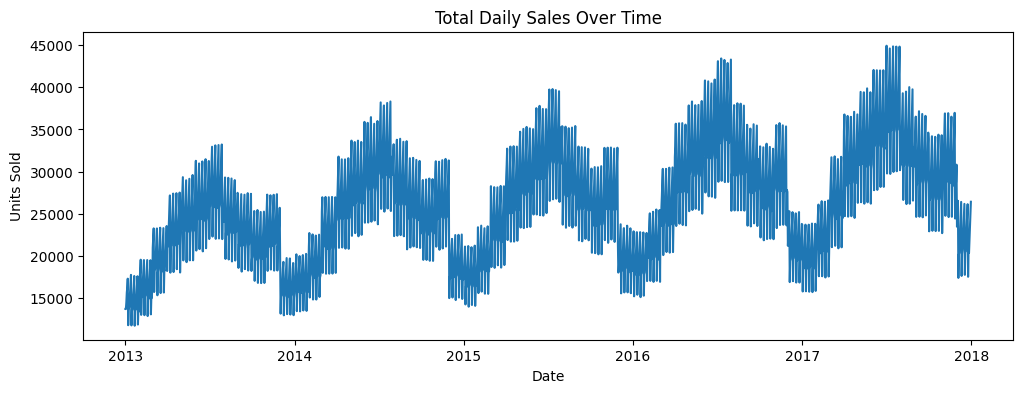

In [5]:
daily_total = df.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(12,4))
plt.plot(daily_total["date"], daily_total["sales"])
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


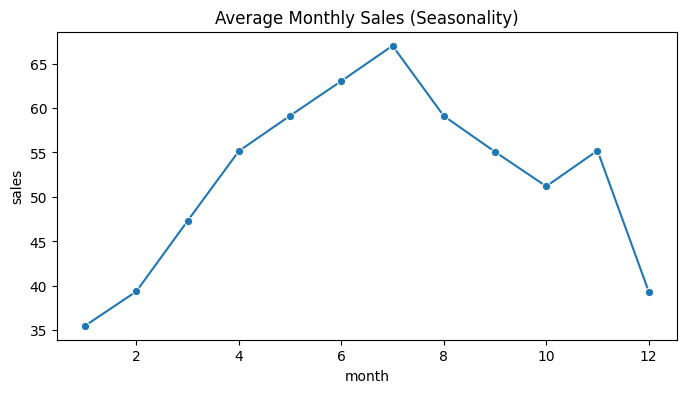

In [6]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

monthly_avg = (
    df.groupby("month", as_index=False)["sales"]
      .mean()
)

plt.figure(figsize=(8,4))
sns.lineplot(data=monthly_avg, x="month", y="sales", marker="o")
plt.title("Average Monthly Sales (Seasonality)")
plt.show()


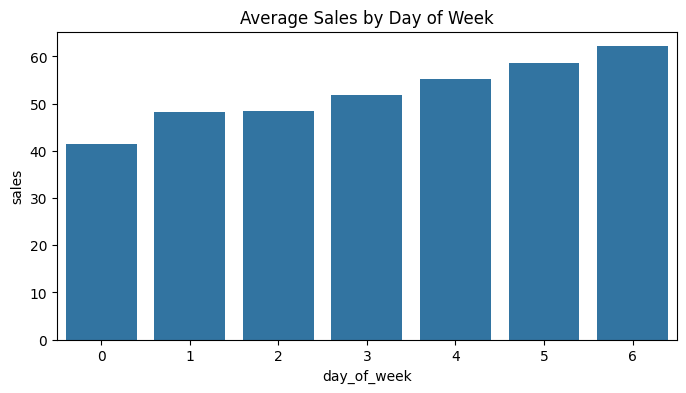

In [7]:
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Mon

weekly_avg = (
    df.groupby("day_of_week", as_index=False)["sales"]
      .mean()
)

plt.figure(figsize=(8,4))
sns.barplot(data=weekly_avg, x="day_of_week", y="sales")
plt.title("Average Sales by Day of Week")
plt.show()


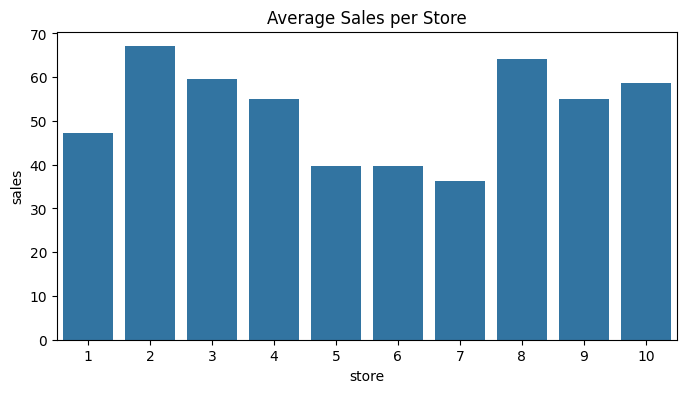

In [8]:
store_avg = (
    df.groupby("store", as_index=False)["sales"]
      .mean()
)

plt.figure(figsize=(8,4))
sns.barplot(data=store_avg, x="store", y="sales")
plt.title("Average Sales per Store")
plt.show()


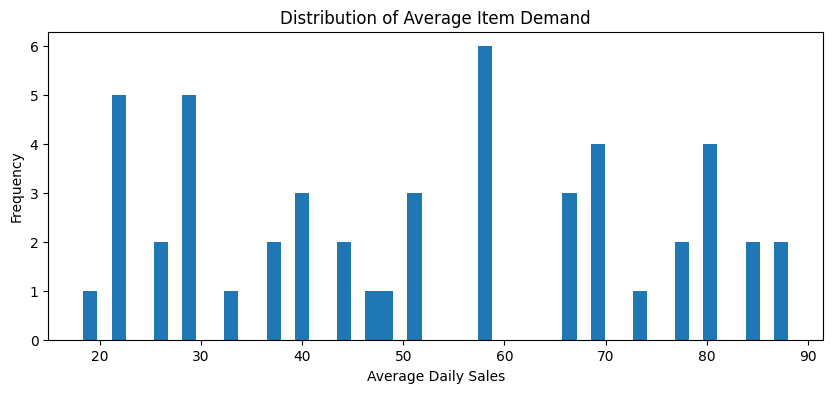

In [9]:
item_sales = df.groupby("item")["sales"].mean()

plt.figure(figsize=(10,4))
item_sales.plot(kind="hist", bins=50)
plt.title("Distribution of Average Item Demand")
plt.xlabel("Average Daily Sales")
plt.show()


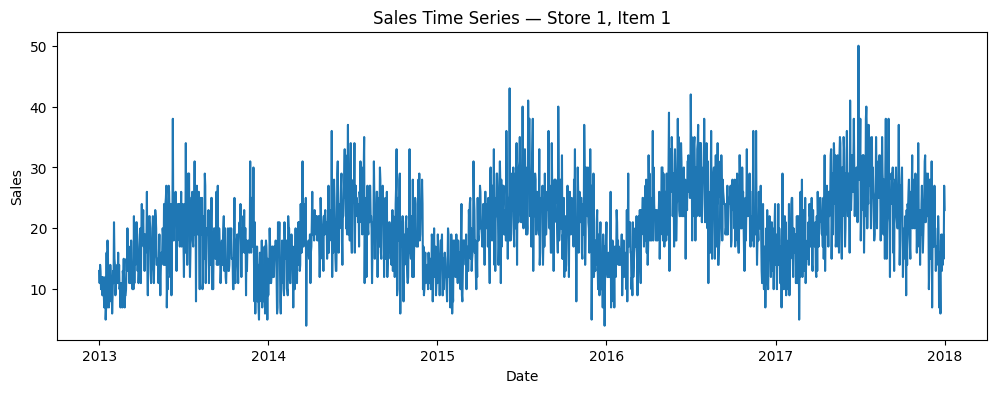

In [10]:
sample_ts = df[(df["store"] == 1) & (df["item"] == 1)]

plt.figure(figsize=(12,4))
plt.plot(sample_ts["date"], sample_ts["sales"])
plt.title("Sales Time Series — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


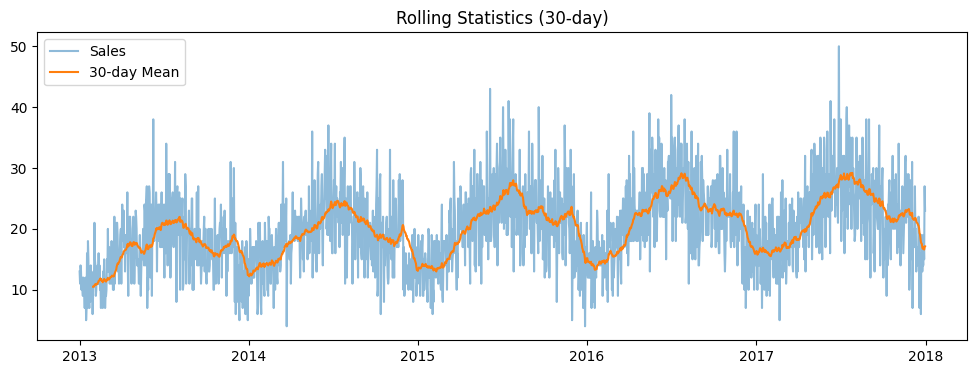

In [11]:
sample_ts = sample_ts.sort_values("date")

sample_ts["rolling_mean_30"] = sample_ts["sales"].rolling(30).mean()
sample_ts["rolling_std_30"] = sample_ts["sales"].rolling(30).std()

plt.figure(figsize=(12,4))
plt.plot(sample_ts["date"], sample_ts["sales"], label="Sales", alpha=0.5)
plt.plot(sample_ts["date"], sample_ts["rolling_mean_30"], label="30-day Mean")
plt.legend()
plt.title("Rolling Statistics (30-day)")
plt.show()
